<a href="https://colab.research.google.com/github/muhhanif27/COMPUTER_REASONING_CBR/blob/main/tugas_uts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial & Tugas UTS: EDA dan Pra-pemrosesan dengan Dask & GCS di Google Colab

## Tujuan Pembelajaran

Dalam tutorial ini, Anda akan belajar cara melakukan analisis data eksplorasi (EDA) dan tugas UTS pra-pemrosesan data menggunakan Dask. Kita akan memproses kumpulan data besar yang disimpan di Google Cloud Storage (GCS) langsung dari Google Colab.

## Bagian 1: Persiapan Environment

### 1. Install Library
Jalankan sel kode berikut untuk menginstal pustaka yang diperlukan (dask).

In [46]:
!pip install gcsfs "dask[complete]"

### 2. Mulai Klaster Dask
Inisialisasi LocalCluster dan Client. Dask akan menggunakan core yang tersedia di mesin virtual Colab.

In [47]:
from dask.distributed import Client, LocalCluster
import dask.dataframe as dd

# Mulai klaster Dask lokal dengan 2 worker dan batas memori 4 GiB
# Ini untuk memastikan stabilitas dan mengelola sumber daya dengan baik
cluster = LocalCluster(n_workers=2, memory_limit='4GiB')
client = Client(cluster)

print(f"Dasbor Dask tersedia di: {client.dashboard_link}")

/usr/local/lib/python3.12/dist-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 41983 instead
  warnings.warn(
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:39965
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:41983/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:34837'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:37291'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:46777 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:46777
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:48582
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:40203 name: 1
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:40203
IN

Dasbor Dask tersedia di: http://127.0.0.1:41983/status


### 3. Muat Data dari GCS
Akses data penerbangan publik dari GCS. Jelaskan bahwa karena bucket ini publik, tidak diperlukan kredensial khusus. Dask secara otomatis menggunakan gcsfs untuk mengakses data.

In [48]:
# Tentukan path GCS ke data
gcs_path = "gcs://quansight-datasets/airline-ontime-performance/csv/*ber_2020.csv"


# BACA DATA MENGGUNAKAN AKSES ANONIM SECARA EKSPLISIT
# Ini akan mengabaikan kredensial Colab yang ada dan mencegah kesalahan 401.
df = dd.read_csv(gcs_path, assume_missing=True, storage_options={'token': 'anon'})
# df = dd.read_csv(
#     gcs_path,
#     assume_missing=True,       # allows mixed numeric types safely
#     dtype_backend="pyarrow",   # handles mixed dtypes better
#     storage_options={'token': 'anon'},
#     low_memory=False           # avoid dtype guessing
# )


## Bagian 2: Analisis Data Eksplorasi (EDA) dengan Dask

### 1. Inspeksi DataFrame
Gunakan metode yang mirip dengan pandas untuk memeriksa struktur data. Pada saat yang diperlukan, gunakan .compute() untuk menjalankan penghitungan.

In [49]:
df = dd.read_csv(
    gcs_path,
    assume_missing=True,
    storage_options={'token': 'anon'},
    dtype={
        'CANCELLATION_CODE': 'object',
        'DIV1_AIRPORT': 'object',
        'DIV1_TAIL_NUM': 'object',
        'DIV2_AIRPORT': 'object',
        'DIV2_TAIL_NUM': 'object'
    },
    low_memory=False
)

In [50]:
# Tampilkan beberapa baris pertama dari Dask DataFrame
print(df.head())

# Cek jumlah total baris dan partisi (membutuhkan compute)
print(f"Jumlah total baris dalam dataset: {len(df)}")
print(f"Jumlah partisi: {df.npartitions}")


     YEAR  QUARTER  MONTH  DAY_OF_MONTH  DAY_OF_WEEK                FL_DATE  \
0  2020.0      4.0   12.0           1.0          2.0  12/1/2020 12:00:00 AM   
1  2020.0      4.0   12.0           1.0          2.0  12/1/2020 12:00:00 AM   
2  2020.0      4.0   12.0           1.0          2.0  12/1/2020 12:00:00 AM   
3  2020.0      4.0   12.0           1.0          2.0  12/1/2020 12:00:00 AM   
4  2020.0      4.0   12.0           1.0          2.0  12/1/2020 12:00:00 AM   

  OP_UNIQUE_CARRIER  OP_CARRIER_AIRLINE_ID OP_CARRIER TAIL_NUM  ...  \
0                9E                20363.0         9E   N131EV  ...   
1                9E                20363.0         9E   N131EV  ...   
2                9E                20363.0         9E   N131EV  ...   
3                9E                20363.0         9E   N131EV  ...   
4                9E                20363.0         9E   N131EV  ...   

   DIV4_WHEELS_OFF  DIV4_TAIL_NUM  DIV5_AIRPORT  DIV5_AIRPORT_ID  \
0              NaN            

### 2. Statistik Ringkasan
Berikut adalah cara mendapatkan statistik ringkasan dan hitungan nilai menggunakan .compute().

In [51]:
# Hitung statistik deskriptif untuk kolom numerik
print(df.describe().compute())

# Hitung jumlah nilai unik untuk kolom 'ORIGIN'
print(df['ORIGIN'].value_counts().compute().head())


            YEAR       QUARTER         MONTH  DAY_OF_MONTH   DAY_OF_WEEK  \
count  1411177.0  1.411177e+06  1.411177e+06  1.411177e+06  1.411177e+06   
mean      2020.0  3.770867e+00  1.055538e+01  1.594778e+01  4.024031e+00   
std          0.0  4.202750e-01  1.109733e+00  8.790429e+00  2.013970e+00   
min       2020.0  3.000000e+00  9.000000e+00  1.000000e+00  1.000000e+00   
25%       2020.0  3.000000e+00  9.000000e+00  9.000000e+00  3.000000e+00   
50%       2020.0  4.000000e+00  1.000000e+01  1.600000e+01  4.000000e+00   
75%       2020.0  4.000000e+00  1.100000e+01  2.400000e+01  6.000000e+00   
max       2020.0  4.000000e+00  1.200000e+01  3.100000e+01  7.000000e+00   

       OP_CARRIER_AIRLINE_ID  OP_CARRIER_FL_NUM  ORIGIN_AIRPORT_ID  \
count           1.411177e+06       1.411177e+06       1.411177e+06   
mean            2.000502e+04       2.669464e+03       1.260339e+04   
std             3.808987e+02       1.845574e+03       1.548834e+03   
min             1.939300e+04       

ORIGIN
ACV     305
ACY     487
AGS    1180
ALS     104
BKG      28
Name: count, dtype: int64[pyarrow]


In [52]:
df['YEAR'].head()

,YEAR
0,2020.0
1,2020.0
2,2020.0
3,2020.0
4,2020.0


### 3. Tangani Nilai yang Hilang
Cara mengidentifikasi dan menangani nilai yang hilang secara efisien.

In [53]:
# Hitung persentase nilai kosong per kolom
null_counts = df.isnull().sum().compute() / len(df)
print(null_counts[null_counts > 0])

# Ganti nilai kosong di kolom 'FL_NUM' dengan nilai rata-rata
df['DEP_DELAY'] = df['DEP_DELAY'].fillna(df['DEP_DELAY'].mean())


TAIL_NUM              0.001625
DEP_TIME              0.006577
DEP_DELAY             0.006579
DEP_DELAY_NEW         0.006579
DEP_DEL15             0.006579
                        ...   
DIV5_WHEELS_ON        1.000000
DIV5_TOTAL_GTIME      1.000000
DIV5_LONGEST_GTIME    1.000000
DIV5_WHEELS_OFF       1.000000
DIV5_TAIL_NUM         1.000000
Length: 71, dtype: float64


## Bagian 3: Pra-pemrosesan Data dengan Dask

### 1. Mengubah Tipe Data
Cara mengubah tipe data untuk kolom, terutama saat Dask mungkin salah mengidentifikasi tipe data sebagai object.

In [54]:
# Ubah kolom 'YEAR' menjadi tipe integer
df['YEAR'] = df['YEAR'].astype(int)

# Ubah kolom bertipe object menjadi tipe category untuk efisiensi
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype('category')


### 2. Rekayasa Fitur
Membuat fitur baru dari kolom yang sudah ada.

In [55]:
# Buat fitur baru untuk durasi penerbangan
df['FLIGHT_DURATION'] = df['ARR_TIME'] - df['DEP_TIME']

### 3. Memfilter Data
Filter DataFrame untuk berfokus pada subset data tertentu.

In [56]:
# Filter penerbangan di tahun 2020 yang mengalami keterlambatan
delayed_flights_2020 = df[(df['YEAR'] == 2020) & (df['ARR_DELAY'] > 0)]

# Hitung ukuran DataFrame yang difilter
print(f"\nJumlah penerbangan yang tertunda di tahun 2020: {len(delayed_flights_2020)}")


Jumlah penerbangan yang tertunda di tahun 2020: 302740


## Bagian 4: Visualisasi dengan Dask dan Matplotlib

### 1. Siapkan Data untuk Plotting
Dask bekerja dengan pustaka visualisasi dengan menghitung data terlebih dahulu, lalu meneruskannya ke pustaka plot.

In [57]:
df.OP_UNIQUE_CARRIER.head()

,OP_UNIQUE_CARRIER
0,9E
1,9E
2,9E
3,9E
4,9E


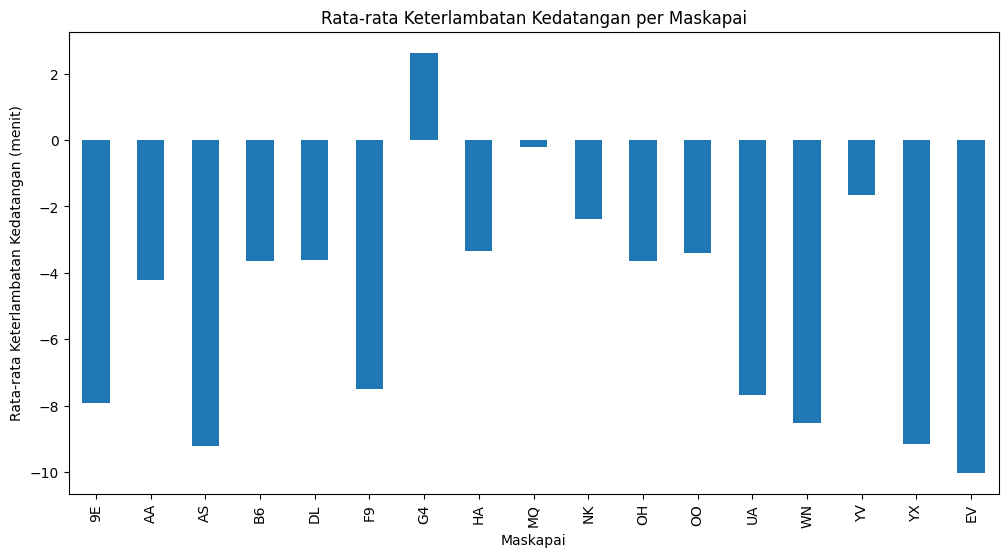

In [58]:
import matplotlib.pyplot as plt

# Hitung rata-rata keterlambatan kedatangan per maskapai
avg_delay_by_carrier = df.groupby('OP_UNIQUE_CARRIER')['ARR_DELAY'].mean().compute()

# Plot hasilnya menggunakan pandas dan matplotlib
plt.figure(figsize=(12, 6))
avg_delay_by_carrier.plot(kind='bar')
plt.title('Rata-rata Keterlambatan Kedatangan per Maskapai')
plt.xlabel('Maskapai')
plt.ylabel('Rata-rata Keterlambatan Kedatangan (menit)')
plt.show()


## Bagian 5: Tugas UTS
Sekarang giliran Anda! Jawab pertanyaan-pertanyaan di bawah ini menggunakan Dask di Google Colab.

### Pertanyaan Konseptual
Jelaskan dengan kata-kata Anda sendiri mengapa Dask diperlukan untuk dataset ini dan masalah apa yang dipecahkannya dibandingkan dengan menggunakan alat single-core seperti pandas.

#### Tuliskan Nama dan NIM di sini

- NAMA: Muhammad Hanif
- NIM: 202210370311265

### Pertanyaan Konseptual

1. Jelaskan dengan kata-kata Anda sendiri mengapa Dask diperlukan untuk dataset ini dan masalah apa yang dipecahkannya dibandingkan dengan menggunakan package single-core seperti pandas.

##### Jawaban:
#ganti-dengan-jawaban-kalian-jangan-buat-cell-baru
Dask diperlukan untuk dataset penerbangan 2020 ini karena ukurannya sangat besar (puluhan GB) dan Pandas tidak mampu menanganinya akibat keterbatasan memori dan pemrosesan single-core. Pandas memuat seluruh data ke RAM sekaligus sehingga menyebabkan out-of-memory error, sementara Dask menggunakan lazy evaluation dan paralelisasi dengan membagi data menjadi partisi kecil, memprosesnya secara bersamaan di beberapa worker (multi-core), serta hanya mengeksekusi komputasi saat diperlukan melalui .compute(), sehingga mampu mengelola data melebihi kapasitas RAM, mempercepat analisis, dan tetap menggunakan sintaks mirip Pandas tanpa mengorbankan skalabilitas atau stabilitas.


### Pertanyaan Pemrograman

2. Hitung rata-rata keterlambatan keberangkatan (DEP_DELAY) untuk setiap maskapai (OP_UNIQUE_CARRIER) dalam dataset. Tampilkan 5 maskapai teratas dengan rata-rata keterlambatan tertinggi.

In [59]:
# Jawab Pertanyaan-2 pada baris berikutnya (baris ini jangan dihapus)


In [60]:
# Hitung rata-rata DEP_DELAY per OP_UNIQUE_CARRIER, urut descending
avg_dep_delay = df.groupby('OP_UNIQUE_CARRIER')['DEP_DELAY'].mean().compute().sort_values(ascending=False).head(5)
print("5 Maskapai dengan Rata-rata Keterlambatan Keberangkatan Tertinggi:")
print(avg_dep_delay)

5 Maskapai dengan Rata-rata Keterlambatan Keberangkatan Tertinggi:
OP_UNIQUE_CARRIER
G4    6.179768
YV    4.254156
OO    2.759895
AA    2.235839
NK    2.127225
Name: DEP_DELAY, dtype: float64


3. Menggunakan kolom FLIGHT_DURATION yang telah dibuat, filter DataFrame untuk menemukan semua penerbangan yang durasinya lebih dari 5 jam. Kemudian, hitung dan tampilkan jumlah total penerbangan tersebut.

In [61]:
# Jawab Pertanyaan-3 pada baris berikutnya (baris ini jangan dihapus)


In [73]:
# Pastikan kolom adalah float (sepertinya sudah, tapi untuk amannya)
df['DEP_TIME'] = df['DEP_TIME'].astype(float)
df['ARR_TIME'] = df['ARR_TIME'].astype(float)

# 1. Konversi DEP_TIME ke total menit
# Operasi ini aman untuk NaN (misal: NaN // 100 menghasilkan NaN)
dep_minutes = (df['DEP_TIME'] // 100) * 60 + (df['DEP_TIME'] % 100)

# 2. Konversi ARR_TIME ke total menit
arr_minutes = (df['ARR_TIME'] // 100) * 60 + (df['ARR_TIME'] % 100)

# 3. Hitung durasi (jika salah satu input NaN, hasilnya akan NaN)
df['FLIGHT_DURATION_MIN'] = arr_minutes - dep_minutes

# 4. Perbaiki untuk penerbangan lewat tengah malam (aman untuk NaN)
df['FLIGHT_DURATION_MIN'] = df['FLIGHT_DURATION_MIN'].where(
    df['FLIGHT_DURATION_MIN'] >= 0,    # Kondisi
    df['FLIGHT_DURATION_MIN'] + 1440  # Apa yang harus dilakukan jika kondisi False
)

# Filter penerbangan dengan durasi lebih dari 5 jam (300 menit)
long_flights = df[df['FLIGHT_DURATION_MIN'] > 300]

# Hitung jumlah total penerbangan tersebut
total_long_flights = long_flights.shape[0].compute()

# Tampilkan hasil
print(f"Jumlah total penerbangan dengan durasi lebih dari 5 jam: {total_long_flights}")


Jumlah total penerbangan dengan durasi lebih dari 5 jam: 91556


4. Buat plot yang menampilkan jumlah total penerbangan yang tertunda (ARR_DELAY > 0) per tahun. Pastikan untuk melabeli plot dengan jelas.

In [63]:
# Jawab Pertanyaan-4 pada baris berikutnya (baris ini jangan dihapus)

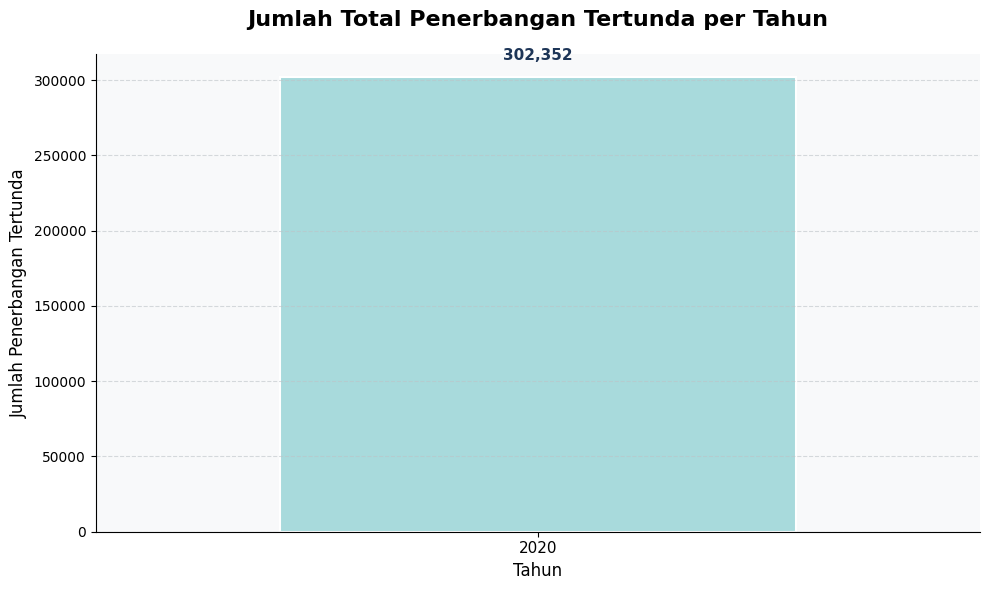

In [64]:
# Filter penerbangan yang mengalami keterlambatan kedatangan
delayed_flights = df[df['ARR_DELAY'] > 0]

# Hitung jumlah penerbangan tertunda per tahun
delays_per_year = delayed_flights.groupby('YEAR').size().compute()
colors = ['#a8dadc', '#457b9d', '#1d3557']

# Plot hasilnya
plt.figure(figsize=(10, 6))
ax = delays_per_year.plot(
    kind='bar',
    color=colors,           # Gradient warna
    edgecolor='white',      # Border putih halus
    linewidth=1.5,
    width=0.7
)

# Styling
plt.title('Jumlah Total Penerbangan Tertunda per Tahun', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Jumlah Penerbangan Tertunda', fontsize=12)
plt.xticks(rotation=0, fontsize=11)

# Grid halus
plt.grid(axis='y', linestyle='--', alpha=0.6, color='#bdc3c7')
ax.set_facecolor('#f8f9fa')  # Latar belakang abu terang

# Hilangkan spine atas & kanan
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Tambahkan nilai di atas setiap bar (dengan format ribuan + tebal)
for i, value in enumerate(delays_per_year):
    plt.text(
        i,
        value + value * 0.03,
        f'{value:,}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
        color='#1d3557'
    )

plt.tight_layout()
plt.show()

5. Pertanyaan Bonus: Buat fitur baru bernama FLIGHT_SPEED (dalam mil per menit) dan gunakan untuk menemukan penerbangan dengan kecepatan tertinggi yang tercatat.

In [65]:
# Jawab Pertanyaan-5 pada baris berikutnya (baris ini jangan dihapus)


In [72]:
import numpy as np
import pandas as pd

possible_duration_cols = ['AIR_TIME', 'ACTUAL_ELAPSED_TIME', 'FLIGHT_DURATION']
duration_col = None
for c in possible_duration_cols:
    if c in df.columns:
        duration_col = c
        break

def hhmm_to_minutes(series):
    s = series.fillna(0).astype(int)
    hours = s // 100
    minutes = s % 100
    return hours * 60 + minutes

if duration_col in ('AIR_TIME', 'ACTUAL_ELAPSED_TIME'):
    df = df.assign(FLIGHT_DURATION_MINUTES = df[duration_col].astype('float64'))
else:
    if 'FLIGHT_DURATION' in df.columns:
        sample = df['FLIGHT_DURATION'].dropna().head(1000).compute()
        if len(sample) > 0 and (sample.abs() <= 1000).all():
            df = df.assign(FLIGHT_DURATION_MINUTES = df['FLIGHT_DURATION'].astype('float64'))
        else:
            if ('ARR_TIME' in df.columns) and ('DEP_TIME' in df.columns):
                def compute_minutes_from_arr_dep(pdf):
                    arr = pdf['ARR_TIME'].fillna(0).astype(int)
                    dep = pdf['DEP_TIME'].fillna(0).astype(int)
                    arr_min = (arr // 100) * 60 + (arr % 100)
                    dep_min = (dep // 100) * 60 + (dep % 100)
                    dur = arr_min - dep_min
                    dur = dur.where(dur >= 0, dur + 24*60)
                    dur = dur.mask(dur <= 0, np.nan)
                    return dur

                df = df.map_partitions(lambda pdf: pdf.assign(FLIGHT_DURATION_MINUTES=compute_minutes_from_arr_dep(pdf)))
            else:
                df = df.assign(FLIGHT_DURATION_MINUTES = np.nan)

if 'DISTANCE' not in df.columns:
    raise ValueError("Kolom 'DISTANCE' tidak ditemukan dalam dataset — tidak bisa menghitung kecepatan.")

df = df.assign(
    FLIGHT_SPEED = df['DISTANCE'] / df['FLIGHT_DURATION_MINUTES']
)

cols_to_pull = ['OP_UNIQUE_CARRIER', 'FL_NUM', 'ORIGIN', 'DEST', 'DISTANCE', 'FLIGHT_DURATION_MINUTES', 'FLIGHT_SPEED']
available_cols = [c for c in cols_to_pull if c in df.columns]

speed_df = df[available_cols].dropna(subset=['FLIGHT_SPEED', 'FLIGHT_DURATION_MINUTES'])

speed_df = speed_df[(speed_df['FLIGHT_DURATION_MINUTES'] > 0) & (speed_df['DISTANCE'] > 0)]

top_fastest = speed_df.compute().sort_values('FLIGHT_SPEED', ascending=False).head(1)

print("Penerbangan dengan kecepatan tertinggi (mil per menit):")
print(top_fastest.to_string(index=False))

Penerbangan dengan kecepatan tertinggi (mil per menit):
OP_UNIQUE_CARRIER ORIGIN DEST  DISTANCE  FLIGHT_DURATION_MINUTES  FLIGHT_SPEED
               G4    FAT  LAS     259.0                     21.0     12.333333


### Bagian 6: Pembersihan
Setelah selesai, tutup klaster Dask.

In [74]:
client.close()
cluster.close()

INFO:distributed.scheduler:Remove client Client-20a692d7-bae9-11f0-814d-0242ac1c000c
INFO:distributed.core:Received 'close-stream' from tcp://127.0.0.1:48602; closing.
INFO:distributed.scheduler:Remove client Client-20a692d7-bae9-11f0-814d-0242ac1c000c
INFO:distributed.scheduler:Close client connection: Client-20a692d7-bae9-11f0-814d-0242ac1c000c
INFO:distributed.scheduler:Retire worker addresses (stimulus_id='retire-workers-1762418346.560535') (0, 1)
INFO:distributed.nanny:Closing Nanny at 'tcp://127.0.0.1:34837'. Reason: nanny-close
INFO:distributed.nanny:Nanny asking worker to close. Reason: nanny-close
INFO:distributed.nanny:Closing Nanny at 'tcp://127.0.0.1:37291'. Reason: nanny-close
INFO:distributed.nanny:Nanny asking worker to close. Reason: nanny-close
INFO:distributed.core:Received 'close-stream' from tcp://127.0.0.1:48582; closing.
INFO:distributed.scheduler:Remove worker addr: tcp://127.0.0.1:46777 name: 0 (stimulus_id='handle-worker-cleanup-1762418346.5701885')
INFO:distri

In [71]:
df

,YEAR,QUARTER,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,FL_DATE,OP_UNIQUE_CARRIER,OP_CARRIER_AIRLINE_ID,OP_CARRIER,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,ORIGIN_CITY_MARKET_ID,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_ABR,ORIGIN_STATE_FIPS,ORIGIN_STATE_NM,ORIGIN_WAC,DEST_AIRPORT_ID,DEST_AIRPORT_SEQ_ID,DEST_CITY_MARKET_ID,DEST,DEST_CITY_NAME,DEST_STATE_ABR,DEST_STATE_FIPS,DEST_STATE_NM,DEST_WAC,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,DEP_DELAY_NEW,DEP_DEL15,DEP_DELAY_GROUP,DEP_TIME_BLK,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,ARR_DELAY_NEW,ARR_DEL15,ARR_DELAY_GROUP,ARR_TIME_BLK,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,FLIGHTS,DISTANCE,DISTANCE_GROUP,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,FIRST_DEP_TIME,TOTAL_ADD_GTIME,LONGEST_ADD_GTIME,DIV_AIRPORT_LANDINGS,DIV_REACHED_DEST,DIV_ACTUAL_ELAPSED_TIME,DIV_ARR_DELAY,DIV_DISTANCE,DIV1_AIRPORT,DIV1_AIRPORT_ID,DIV1_AIRPORT_SEQ_ID,DIV1_WHEELS_ON,DIV1_TOTAL_GTIME,DIV1_LONGEST_GTIME,DIV1_WHEELS_OFF,DIV1_TAIL_NUM,DIV2_AIRPORT,DIV2_AIRPORT_ID,DIV2_AIRPORT_SEQ_ID,DIV2_WHEELS_ON,DIV2_TOTAL_GTIME,DIV2_LONGEST_GTIME,DIV2_WHEELS_OFF,DIV2_TAIL_NUM,DIV3_AIRPORT,DIV3_AIRPORT_ID,DIV3_AIRPORT_SEQ_ID,DIV3_WHEELS_ON,DIV3_TOTAL_GTIME,DIV3_LONGEST_GTIME,DIV3_WHEELS_OFF,DIV3_TAIL_NUM,DIV4_AIRPORT,DIV4_AIRPORT_ID,DIV4_AIRPORT_SEQ_ID,DIV4_WHEELS_ON,DIV4_TOTAL_GTIME,DIV4_LONGEST_GTIME,DIV4_WHEELS_OFF,DIV4_TAIL_NUM,DIV5_AIRPORT,DIV5_AIRPORT_ID,DIV5_AIRPORT_SEQ_ID,DIV5_WHEELS_ON,DIV5_TOTAL_GTIME,DIV5_LONGEST_GTIME,DIV5_WHEELS_OFF,DIV5_TAIL_NUM,FLIGHT_DURATION,DEP_MINUTES,ARR_MINUTES,FLIGHT_DURATION_MINUTES,FLIGHT_SPEED,DEP_MIN,ARR_MIN,FLIGHT_DURATION_MIN
npartitions=7,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
,int64,float64,float64,float64,float64,string,string,float64,string,string,float64,float64,float64,float64,string,string,string,float64,string,float64,float64,float64,float64,string,string,string,float64,string,float64,float64,float64,float64,float64,float64,float64,string,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,string,float64,string,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,string,float64,float64,float64,float64,float64,float64,string,string,float64,float64,float64,float64,float64,float64,string,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...